##Capa Bronze
####1: Conjunto de datos sintético — 2,000 transacciones Yape

In [0]:
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import *
np.random.seed(42)

n = 2000
distritos = ["Miraflores", "San Isidro", "SJL", "Comas", "Villa El Salvador",
             "Los Olivos", "Surco", "Ate", "Callao", "Independencia"]
tipos     = ["persona_a_persona", "persona_a_comercio", "retiro_bcp", "recarga"]
estados   = ["completada", "completada", "completada", "rechazada", "pendiente"]

data = {
    "id_transaccion": [f"YP{i:07d}" for i in range(1, n+1)],
    "fecha":          pd.date_range("2025-01-01", periods=n, freq="1h").strftime("%Y-%m-%d").tolist(),
    "hora":           [f"{h:02d}:{m:02d}" for h, m in zip(np.random.randint(0,24,n), np.random.randint(0,60,n))],
    "monto_soles":    np.round(np.random.exponential(45, n), 2).tolist(),
    "tipo":           np.random.choice(tipos, n).tolist(),
    "distrito_origen":np.random.choice(distritos, n).tolist(),
    "estado":         np.random.choice(estados, n, p=[0.75, 0.1, 0.05, 0.07, 0.03]).tolist(),
    "id_usuario":     [f"USR{np.random.randint(1000,9999)}" for _ in range(n)],
    "es_comercio":    np.random.choice([True, False], n, p=[0.4, 0.6]).tolist()
}

df_pandas = pd.DataFrame(data)
df_bronze = spark.createDataFrame(df_pandas)
df_bronze.write.mode("overwrite").saveAsTable("default.transacciones_bronze")

print(f"✅ Bronze layer: {df_bronze.count()} transacciones guardadas")
df_bronze.show(5)

✅ Bronze layer: 2000 transacciones guardadas
+--------------+----------+-----+-----------+------------------+---------------+----------+----------+-----------+
|id_transaccion|     fecha| hora|monto_soles|              tipo|distrito_origen|    estado|id_usuario|es_comercio|
+--------------+----------+-----+-----------+------------------+---------------+----------+----------+-----------+
|     YP0000001|2025-01-01|06:25|      35.47| persona_a_persona|          Surco|completada|   USR9055|      false|
|     YP0000002|2025-01-01|19:07|       4.16|persona_a_comercio|          Surco|completada|   USR4216|       true|
|     YP0000003|2025-01-01|14:35|      42.01|        retiro_bcp|     San Isidro|completada|   USR6688|      false|
|     YP0000004|2025-01-01|10:47|        7.4|        retiro_bcp|     Los Olivos|completada|   USR5364|      false|
|     YP0000005|2025-01-01|07:29|       1.41|           recarga|     San Isidro|completada|   USR7042|      false|
+--------------+----------+-----+--

##Capa Silver
####2: limpiar y transformar

In [0]:
# ============================================================
# CELDA 2: Silver — limpiar y transformar (Formato Oficial)
# ============================================================
from pyspark.sql import functions as F

# Leemos la tabla del catálogo que guardamos en la celda 1
df_bronze = spark.read.table("default.transacciones_bronze")

df_silver = df_bronze \
    .filter(df_bronze.estado == "completada") \
    .filter(df_bronze.monto_soles > 0) \
    .withColumn("categoria_monto",
        F.when(F.col("monto_soles") < 20, "micro")
         .when(F.col("monto_soles") < 100, "medio")
         .otherwise("alto")) \
    .withColumn("es_hora_pico",
        F.when(F.col("hora").between("12:00", "14:00"), True)
         .when(F.col("hora").between("18:00", "22:00"), True)
         .otherwise(False)) \
    .withColumn("comision_yape",
        F.when(F.col("tipo") == "persona_a_comercio",
               F.round(F.col("monto_soles") * 0.015, 2))
         .otherwise(0.0))

# Guardamos el resultado en el catálogo seguro de Databricks
df_silver.write.mode("overwrite").saveAsTable("default.transacciones_silver")

# Mostramos los resultados en pantalla con la sintaxis correcta
print(f"✅ Silver layer: {df_silver.count()} transacciones completas")
print(f"   Eliminadas: {df_bronze.count() - df_silver.count()} (rechazadas/pendientes/monto cero)")
df_silver.groupBy("categoria_monto").count().show()

✅ Silver layer: 1802 transacciones completas
   Eliminadas: 198 (rechazadas/pendientes/monto cero)
+---------------+-----+
|categoria_monto|count|
+---------------+-----+
|           alto|  202|
|          micro|  634|
|          medio|  966|
+---------------+-----+



##Capa Gold
####3:  agregaciones para el tablero ejecutivo

In [0]:
# ============================================================
# CELDA 3: Gold — agregaciones para el dashboard ejecutivo
# ============================================================
# Leemos la tabla limpia catalogada en la Celda 2
df_silver = spark.read.table("default.transacciones_silver")
df_silver.createOrReplaceTempView("transacciones")

# Gold 1: Top 5 distritos por volumen de transacciones
gold_distritos = spark.sql("""
    SELECT 
        distrito_origen,
        COUNT(*)                          AS total_transacciones,
        ROUND(SUM(monto_soles), 2)        AS volumen_total_soles,
        ROUND(AVG(monto_soles), 2)        AS ticket_promedio,
        SUM(CASE WHEN es_comercio THEN 1 ELSE 0 END) AS transacciones_comercio
    FROM transacciones
    GROUP BY distrito_origen
    ORDER BY total_transacciones DESC
    LIMIT 5
""")

# Gold 2: Ingresos Yape por hora del día (comisiones de comercios)
gold_comisiones = spark.sql("""
    SELECT
        SUBSTRING(hora, 1, 2)             AS hora_dia,
        COUNT(*)                          AS num_transacciones,
        ROUND(SUM(comision_yape), 2)      AS ingresos_yape_soles
    FROM transacciones
    WHERE comision_yape > 0
    GROUP BY SUBSTRING(hora, 1, 2)
    ORDER BY ingresos_yape_soles DESC
""")

# Guardamos los resultados en el catálogo para la celda de gráficos
gold_distritos.write.mode("overwrite").saveAsTable("default.gold_top_distritos")
gold_comisiones.write.mode("overwrite").saveAsTable("default.gold_ingresos_por_hora")

print("📊 TOP 5 DISTRITOS POR VOLUMEN YAPE:")
gold_distritos.show()

print("💰 INGRESOS YAPE POR HORA (comisión comercios):")
gold_comisiones.show(5)

📊 TOP 5 DISTRITOS POR VOLUMEN YAPE:
+---------------+-------------------+-------------------+---------------+----------------------+
|distrito_origen|total_transacciones|volumen_total_soles|ticket_promedio|transacciones_comercio|
+---------------+-------------------+-------------------+---------------+----------------------+
|  Independencia|                204|            8968.04|          43.96|                    75|
|     San Isidro|                197|            8194.34|           41.6|                    71|
|     Los Olivos|                190|            8505.19|          44.76|                    79|
|         Callao|                186|            8929.61|          48.01|                    77|
|     Miraflores|                179|            8295.37|          46.34|                    65|
+---------------+-------------------+-------------------+---------------+----------------------+

💰 INGRESOS YAPE POR HORA (comisión comercios):
+--------+-----------------+---------------

##Visualización (ya escrita, ejecutar tal cual)
####4: Visualización — gráfico de barras con matplotlib

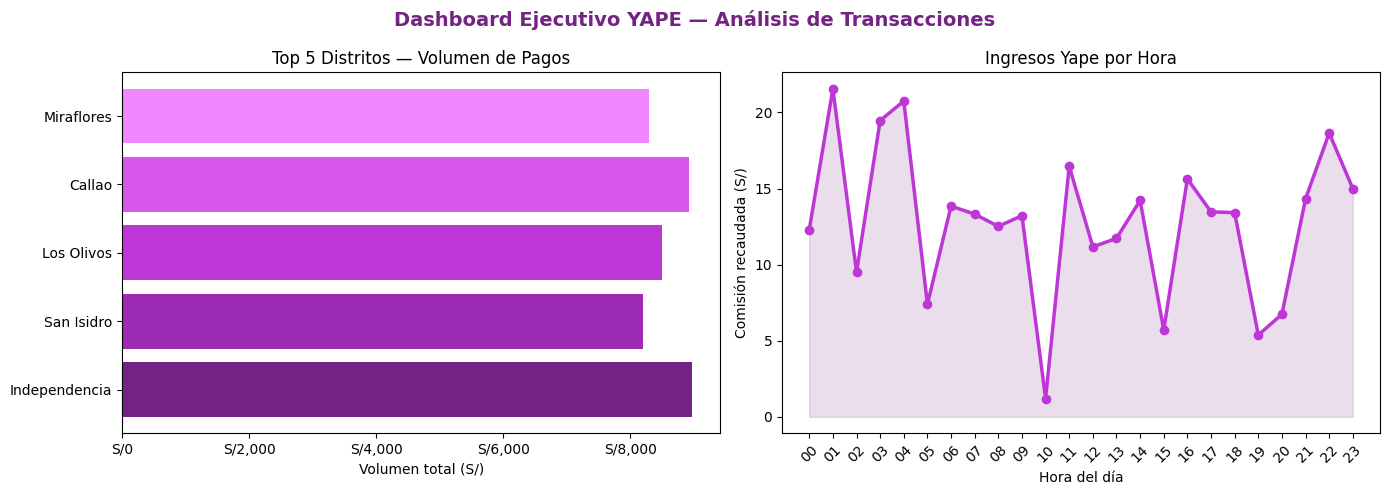

✅ Dashboard generado con colores de identidad Yape


In [0]:
# ============================================================
# CELDA 4: Visualización — Dashboard Ejecutivo YAPE (Paleta Llamativa Yape)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Cargamos los datos del catálogo directamente a DataFrames de Pandas
gold_distritos_pd = spark.read.table("default.gold_top_distritos").toPandas()
gold_comisiones_pd = spark.read.table("default.gold_ingresos_por_hora").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dashboard Ejecutivo YAPE — Análisis de Transacciones", fontsize=14, fontweight='bold', color='#742284')

# Gráfico 1: Top 5 distritos por volumen (Paleta Violeta/Fucsia llamativa)
# Usamos colores vibrantes característicos de la marca
colores_yape = ["#742284", "#9d2bb3", "#bf36d6", "#d957ed", "#f188ff"]
axes[0].barh(gold_distritos_pd["distrito_origen"], gold_distritos_pd["volumen_total_soles"],
             color=colores_yape)
axes[0].set_xlabel("Volumen total (S/)")
axes[0].set_title("Top 5 Distritos — Volumen de Pagos")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S/{x:,.0f}"))

# Gráfico 2: Ingresos Yape por hora (comisiones)
gold_comisiones_sorted = gold_comisiones_pd.sort_values("hora_dia")
# Línea en fucsia encendido con marcador
axes[1].plot(gold_comisiones_sorted["hora_dia"], gold_comisiones_sorted["ingresos_yape_soles"],
             marker='o', color='#bf36d6', linewidth=2.5)
# Relleno traslúcido violeta
axes[1].fill_between(gold_comisiones_sorted["hora_dia"], gold_comisiones_sorted["ingresos_yape_soles"],
                     alpha=0.15, color='#742284')
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("Comisión recaudada (S/)")
axes[1].set_title("Ingresos Yape por Hora")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Dashboard generado con colores de identidad Yape")